In [1]:
import gc
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import rankdata
from matplotlib import pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
import dagshub
import mlflow
import mlflow.lightgbm
import mlflow.pytorch

from src.config import DAGSHUB_USERNAME, DAGSHUB_REPO
from src.config import TARGET, TIME_COL, UID_COL, processed_dataset
from src.evaluation.rank_normalization import rank_norm_blend_models




c:\Users\ADMIN\Documents\DataScience\ieee-fraud-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

dagshub.init(
    repo_owner=DAGSHUB_USERNAME,
    repo_name=DAGSHUB_REPO,
    mlflow=True
)

mlflow.set_experiment("ieee-fraud-ensemble")
print(f"Connected to MLflow: {mlflow.get_tracking_uri()}")

Accessing as anamish05

Initialized MLflow to track repo "anamish05/ieee-fraud-detection"

Repository anamish05/ieee-fraud-detection initialized!

Connected to MLflow: https://dagshub.com/anamish05/ieee-fraud-detection.mlflow


In [3]:

df = pd.read_parquet(processed_dataset)
df = df.sort_values(TIME_COL).reset_index(drop=True)

# 80/20 chronological holdout (matches NN model)
n_samples = len(df)
split_idx = int(n_samples * 0.8)
idx_val_time = np.arange(split_idx, n_samples)

y_val = df[TARGET].iloc[idx_val_time].to_numpy(dtype=np.float32)
print(f"Validation set size: {len(y_val):,} rows | Fraud rate: {y_val.mean():.4f}")

Validation set size: 118,108 rows | Fraud rate: 0.0344


In [4]:
# Run IDs from DagsHub 
LGB_RUN_ID = "2cb61070639a410f8dd5c1a09571ce4b"
NN_RUN_ID = "4075eac73e8245998b8c1ca1eb1655b5"

# 1. Load LightGBM booster
print(f"Loading LightGBM model from run {LGB_RUN_ID}...")
model = mlflow.lightgbm.load_model("models:/m-c3862ad87dac424fbcc70e3bc580ea61")

# 2. Download NN Validation Predictions directly from DagsHub artifact store
# (Faster and saves loading PyTorch tensors, sentence transformers, and GPU memory)
client = mlflow.tracking.MlflowClient()

print(f"Fetching NN validation predictions from run {NN_RUN_ID}...")
pred_artifact_path = client.download_artifacts(
    run_id=NN_RUN_ID, 
    path="predictions/multimodal_seq128_01_oof_preds.npy"
)
nn_val_preds = np.load(pred_artifact_path)

# Verify alignment
assert len(nn_val_preds) == len(y_val), (
    f"Shape mismatch! NN preds ({len(nn_val_preds)}) != y_val ({len(y_val)})"
)
print("Successfully loaded both models and predictions.")

Loading LightGBM model from run 2cb61070639a410f8dd5c1a09571ce4b...


Fetching NN validation predictions from run 4075eac73e8245998b8c1ca1eb1655b5...


Successfully loaded both models and predictions.


In [5]:
# align window of validation - easier to make it 80/20 for LGBM and just download preds for NN, then compare 
# Prepare features list (dropping non-feature columns identical to track LGBM logic)
te_features = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M4']
drop_cols = [
    TARGET, 
    TIME_COL, 
    UID_COL
] + te_features

features = [c for c in df.columns if c not in drop_cols]
td_cols = df[features].select_dtypes(include=["timedelta", "datetime"]).columns.tolist()
for c in td_cols:
    df[c] = df[c].dt.total_seconds().astype("float32")

# Extract validation feature slice
X_va_lgb = df.iloc[idx_val_time][features]

# Predict probabilities with LightGBM
lgb_val_preds = model.predict(X_va_lgb)

del df, X_va_lgb
gc.collect()

print("LightGBM prediction complete.")

LightGBM prediction complete.


In [6]:
# rank normalization of the prediction probabilities 
# blend together predictions 

results_df, best_weight, best_auc, delta_vs_lgb = rank_norm_blend_models(lgb_val_preds, nn_val_preds, y_val)
print("\n--- Blending Weight Search ---")
print(results_df.to_string(index=False))

print("\n" + "=" * 55)
print(f"Optimal Blend: LGB {best_weight[0]:.2f} + NN {best_weight[1]:.2f}")
print(f"Best ROC-AUC : {best_auc:.5f} (Delta vs LGB: {delta_vs_lgb:+.5f})")
print("=" * 55)

Rank Correlation between LGBM and NN: 0.6249
Note: Lower correlation (< 0.90) indicates high diversity and maximum ensemble lift.

LGBM Standalone | ROC-AUC: 0.94272 | PR-AUC: 0.66854
NN   Standalone | ROC-AUC: 0.88958 | PR-AUC: 0.50286

--- Blending Weight Search ---
 w_lgb  w_nn      auc    prauc  delta_vs_lgb
  0.00  1.00 0.889581 0.502862     -0.053142
  0.05  0.95 0.894749 0.529370     -0.047974
  0.10  0.90 0.899506 0.542158     -0.043217
  0.15  0.85 0.903988 0.552734     -0.038735
  0.20  0.80 0.908235 0.561801     -0.034488
  0.25  0.75 0.912266 0.569967     -0.030457
  0.30  0.70 0.916087 0.577457     -0.026636
  0.35  0.65 0.919677 0.584374     -0.023046
  0.40  0.60 0.923049 0.590857     -0.019674
  0.45  0.55 0.926183 0.597094     -0.016540
  0.50  0.50 0.929067 0.603186     -0.013656
  0.55  0.45 0.931679 0.609142     -0.011044
  0.60  0.40 0.934022 0.615014     -0.008701
  0.65  0.35 0.936099 0.620905     -0.006624
  0.70  0.30 0.937918 0.626958     -0.004805
  0.75  0.2

In [7]:
rank_lgb = (rankdata(lgb_val_preds) - 1.0) / (len(lgb_val_preds) - 1.0)
rank_nn = (rankdata(nn_val_preds) - 1.0) / (len(nn_val_preds) - 1.0)
pred_corr = np.corrcoef(rank_lgb, rank_nn)[0, 1]

lgb_auc = roc_auc_score(y_val, rank_lgb)
nn_auc = roc_auc_score(y_val, rank_nn)

print(f"LGB PR-AUC     : {average_precision_score(y_val, rank_lgb):.5f}")
print(f"Ensemble PR-AUC: {average_precision_score(y_val, (0.95*rank_lgb + 0.05*rank_nn)):.5f}")

LGB PR-AUC     : 0.66854
Ensemble PR-AUC: 0.66185


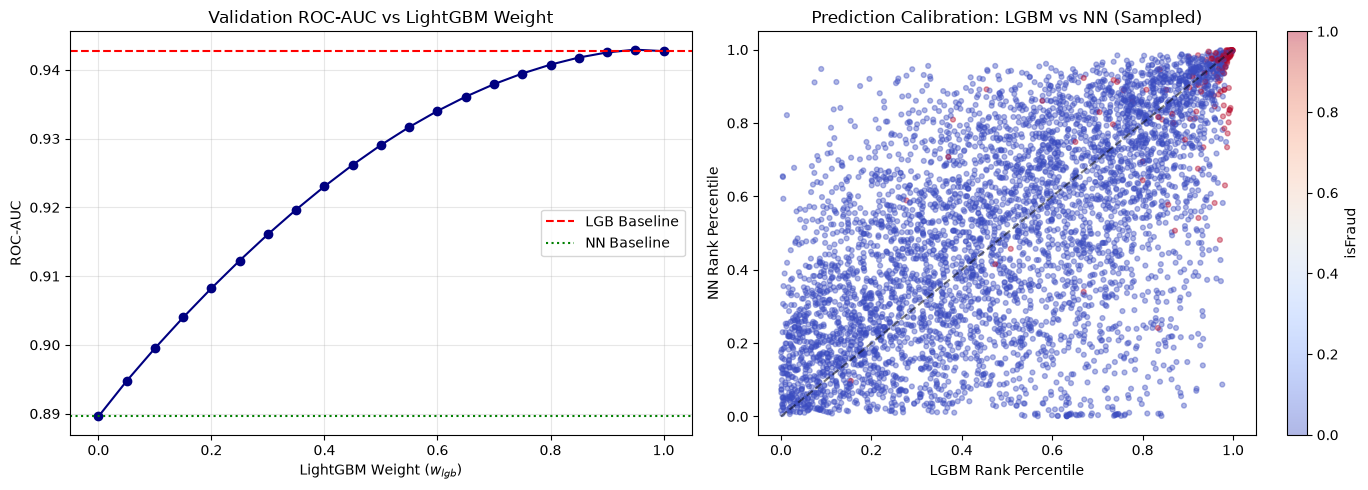

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Weight curve
ax1.plot(results_df['w_lgb'], results_df['auc'], marker='o', color='navy')
ax1.axhline(lgb_auc, linestyle='--', color='red', label='LGB Baseline')
ax1.axhline(nn_auc, linestyle=':', color='green', label='NN Baseline')
ax1.set_title("Validation ROC-AUC vs LightGBM Weight")
ax1.set_xlabel("LightGBM Weight ($w_{lgb}$)")
ax1.set_ylabel("ROC-AUC")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Prediction Scatter (checking ensemble disagreement)
sample_idx = np.random.choice(len(y_val), size=5000, replace=False)
scatter = ax2.scatter(
    rank_lgb[sample_idx], 
    rank_nn[sample_idx], 
    c=y_val[sample_idx], 
    cmap='coolwarm', 
    alpha=0.4, 
    s=12
)
ax2.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)
ax2.set_title("Prediction Calibration: LGBM vs NN (Sampled)")
ax2.set_xlabel("LGBM Rank Percentile")
ax2.set_ylabel("NN Rank Percentile")
fig.colorbar(scatter, ax=ax2, label="isFraud")

plt.tight_layout()

In [9]:
# save to DagsHub

with mlflow.start_run(run_name="ensemble_lgb_nn_blend"):
    # Log hyperparameters and weights
    mlflow.log_params({
        "lgb_run_id": LGB_RUN_ID,
        "nn_run_id": NN_RUN_ID,
        "best_w_lgb": float(best_weight[0]),
        "best_w_nn": float(best_weight[1]),
        "ensemble_type": "rank_average"
    })
    
    # Log individual and blend metrics
    mlflow.log_metrics({
        "lgb_standalone_auc": float(lgb_auc),
        "nn_standalone_auc": float(nn_auc),
        "ensemble_best_auc": float(best_auc),
        "auc_lift_vs_lgb": float(best_auc - lgb_auc),
        "prediction_correlation": float(pred_corr)
    })
    
    
    print("Ensemble experiment successfully logged to DagsHub!")

Ensemble experiment successfully logged to DagsHub!
🏃 View run ensemble_lgb_nn_blend at: https://dagshub.com/anamish05/ieee-fraud-detection.mlflow/#/experiments/2/runs/319fbd210b5b4dd4a0bac9389ee6cfda
🧪 View experiment at: https://dagshub.com/anamish05/ieee-fraud-detection.mlflow/#/experiments/2
